# LAB 02 — Language Models: Experiments

Corpus: `c4-train.00000-of-01024-30K.json.gz` (C4), dùng **10,000 documents đầu** (đề cho phép 10K–30K;
chọn 10K để vừa RAM khi lưu trigram counts bằng dict Python).
Đặt file tại `lab02/data/` hoặc đặt biến môi trường `LAB02_CORPUS`.


In [1]:
import copy, gzip, json, math, os, random, time
from collections import Counter
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from ngram_lm import (NGramLanguageModel, tokenize, split_sentences, count_ngrams,
                      build_vocabulary, BOS, EOS, UNK)

pd.set_option("display.width", 200)
CORPUS = Path(os.environ.get("LAB02_CORPUS", "data/c4-train.00000-of-01024-30K.json.gz"))
N_DOCS, SEED, MIN_COUNT = 10_000, 42, 2

docs = []
with gzip.open(CORPUS, "rt", encoding="utf-8") as f:
    for line in f:
        docs.append(json.loads(line)["text"])
        if len(docs) >= N_DOCS:
            break

# Chia theo DOCUMENT (không theo câu) để câu của cùng một trang web không nằm ở cả train và test.
random.Random(SEED).shuffle(docs)
n_tr, n_va = int(0.8 * len(docs)), int(0.1 * len(docs))
split_docs = {"train": docs[:n_tr], "valid": docs[n_tr:n_tr + n_va], "test": docs[n_tr + n_va:]}

def to_sentences(ds):
    out = [tokenize(s) for d in ds for s in split_sentences(d)]
    return [s for s in out if s]

data = {k: to_sentences(v) for k, v in split_docs.items()}
for k, v in data.items():
    print(f"{k:5s}: {len(split_docs[k]):5d} docs, {len(v):6d} sentences, {sum(map(len, v)):8d} tokens")

train:  8000 docs, 166282 sentences,  2913053 tokens
valid:  1000 docs,  21471 sentences,   377229 tokens
test :  1000 docs,  20201 sentences,   369731 tokens


## Mục 13 — Experiment 1: Corpus statistics (train set)
N-gram được đếm trên câu đã pad (`<s>` ở đầu, `</s>` ở cuối), **chưa** thay từ hiếm bằng `<unk>`.

In [2]:
train = data["train"]
vocab_all = build_vocabulary(train)
vocab_mc = build_vocabulary(train, MIN_COUNT)
stats = {
    "documents": len(split_docs["train"]),
    "sentences": len(train),
    "tokens": sum(map(len, train)),
    "vocabulary size": len(vocab_all),
    f"vocabulary size (min_count={MIN_COUNT})": len(vocab_mc),
}
freq = {}
rows = []
for n, name in [(1, "Unigram"), (2, "Bigram"), (3, "Trigram")]:
    c = count_ngrams(train, n, pad=(n > 1))
    values = sorted(c.values(), reverse=True)
    singletons = sum(1 for v in values if v == 1)
    rows.append({"Model": name, "# unique n-grams": len(values), "# n-gram xuất hiện 1 lần": singletons,
                 "% singletons": round(100 * singletons / len(values), 1), "# n-gram tokens": sum(values)})
    freq[name] = values
    del c
for k, v in stats.items():
    print(f"{k:32s} {v:>10,}")
ngram_stats = pd.DataFrame(rows)
print()
print(ngram_stats.to_string(index=False))

documents                             8,000
sentences                           166,282
tokens                            2,913,053
vocabulary size                      87,224
vocabulary size (min_count=2)        47,699

  Model  # unique n-grams  # n-gram xuất hiện 1 lần  % singletons  # n-gram tokens
Unigram             87224                     39525          45.3          2913053
 Bigram           1025840                    747531          72.9          3079335
Trigram           2139310                   1876967          87.7          3079335


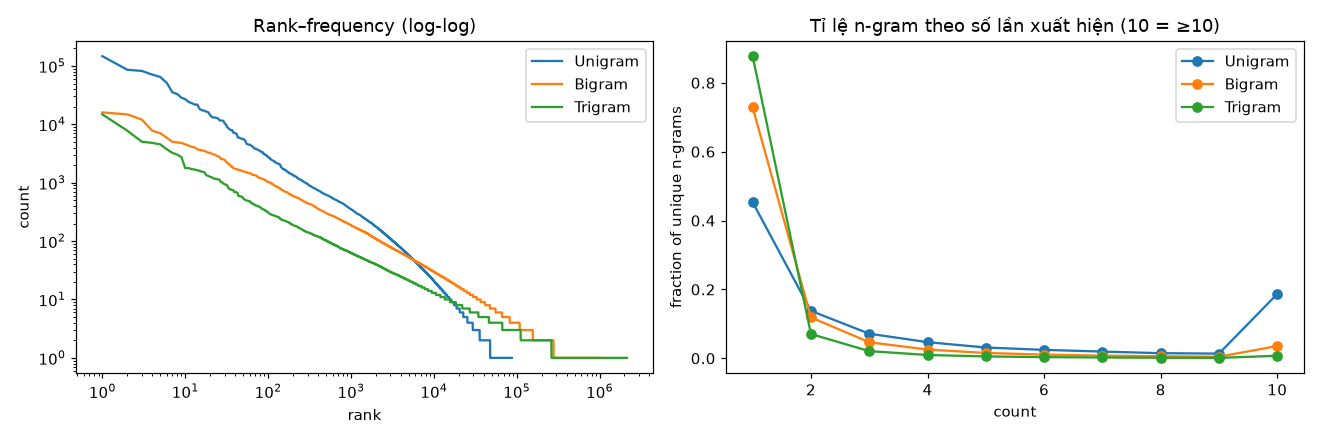

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, values in freq.items():
    axes[0].loglog(range(1, len(values) + 1), values, label=name)
    hist = Counter(min(v, 10) for v in values)
    axes[1].plot(range(1, 11), [hist[i] / len(values) for i in range(1, 11)], marker="o", label=name)
axes[0].set(title="Rank–frequency (log-log)", xlabel="rank", ylabel="count"); axes[0].legend()
axes[1].set(title="Tỉ lệ n-gram theo số lần xuất hiện (10 = ≥10)", xlabel="count", ylabel="fraction of unique n-grams")
axes[1].legend()
fig.tight_layout()
plt.show()
for name, values in freq.items():
    print(f"top-5 {name} counts: {values[:5]}")
del freq

**Nhận xét Experiment 1 (mục 13)**

Vocabulary:
- 87,224 từ (all) → 47,699 từ (min_count=2), tức khoảng 45% từ chỉ xuất hiện 1 lần.
- Vocabulary size không phụ thuộc vào n — cả 3 model dùng chung vocab từ train.

Số unique n-gram tăng rất nhanh:
- Unigram: 87,224
- Bigram: 1,025,840
- Trigram: 2,139,310

Tỉ lệ singleton (n-gram xuất hiện 1 lần) tăng theo n:
- Unigram: 45.3%
- Bigram: 72.9%
- Trigram: 87.7%

Nhận xét:
1. Phần lớn n-gram chỉ xuất hiện 1 lần → sparsity rất nghiêm trọng, đặc biệt với trigram.
2. Phân phối tần suất tuân theo Zipf's law: một số ít n-gram xuất hiện rất nhiều, phần lớn xuất hiện rất ít.
3. Khi n tăng, số tổ hợp context tăng theo cấp số nhân, nhưng dữ liệu hữu hạn → tỉ lệ singleton tăng mạnh.
4. Hệ quả: càng lên bậc cao, model càng dễ gặp n-gram chưa thấy → zero probability nhiều hơn.


## Train các model, tính perplexity (mục 16, 19, 23)
- Vocabulary lấy từ train với `min_count = 2`; từ hiếm và từ lạ ở valid/test → `<unk>`.
- MLE và Laplace dùng **chung** bảng count, chỉ khác công thức `probability()`.
- `PPL = inf` nghĩa là có ít nhất một token có xác suất 0; cột `zero-prob %` cho biết tỉ lệ token đó.
- Unseen n-gram: tỉ lệ n-gram (sau khi map `<unk>`) của valid/test không có trong train.

In [4]:
def with_smoothing(lm, smoothing):
    m = copy.copy(lm)  # shallow copy: dùng chung counts
    m.smoothing = smoothing
    return m

def unseen_rate(lm, sentences):
    total = unseen = 0
    for s in sentences:
        toks = lm._prepare(s)
        for i in range(len(toks) - lm.n + 1):
            total += 1
            unseen += tuple(toks[i:i + lm.n]) not in lm.ngram_counts
    return unseen / total

# Next-word prediction: context lấy từ test set (mục 20, 22)
rng = random.Random(SEED)
test_positions = []
while len(test_positions) < 200:
    s = rng.choice(data["test"])
    if len(s) >= 3:
        i = rng.randrange(2, len(s))
        test_positions.append((tuple(s[i - 2:i]), s[i]))

manual_contexts = ["the cat", "natural language", "machine learning", "i want to", "in the", "the united", "how to"]

def followers(lm, contexts):
    """Một lần quét counts để lấy các từ đã theo sau mỗi context (nhanh hơn gọi riêng từng context)."""
    want = {c: Counter() for c in contexts}
    for g, c in lm.ngram_counts.items():
        h = g[:-1]
        if h in want:
            want[h][g[-1]] = c
    return want

def map_ctx(lm, ctx):
    ctx = [t if t in lm.vocab else UNK for t in ctx]
    if len(ctx) < lm.n - 1:
        ctx = [BOS] * (lm.n - 1 - len(ctx)) + ctx
    return tuple(ctx[-(lm.n - 1):]) if lm.n > 1 else ()

ranking_context = "machine learning"
ranking_candidates = {"A": "is useful for NLP", "B": "banana computer quickly", "C": "studies language models"}

ppl_rows, ctx_rows, nwp_manual, nwp_samples, rank_rows = [], [], [], [], []
for n, name in [(1, "Unigram"), (2, "Bigram"), (3, "Trigram")]:
    t0 = time.time()
    lm = NGramLanguageModel(n, "mle", min_count=MIN_COUNT).fit(train)
    for smoothing in ("mle", "laplace"):
        m = with_smoothing(lm, smoothing)
        row = {"Model": f"{name} {'MLE' if smoothing == 'mle' else 'Laplace'}", "n": n, "smoothing": smoothing}
        for split in ("train", "valid", "test"):
            r = m.evaluate(data[split])
            row[f"{split} PPL"] = r["perplexity"]
            row[f"{split} zero-prob %"] = round(100 * r["zero_prob_rate"], 3)
        ppl_rows.append(row)
    ctx_rows.append({"n": n, "# unique n-grams (train, <unk>)": len(lm.ngram_counts),
                     "unseen n-gram % (valid)": round(100 * unseen_rate(lm, data["valid"]), 2),
                     "unseen n-gram % (test)": round(100 * unseen_rate(lm, data["test"]), 2)})
    if n >= 2:
        lap = with_smoothing(lm, "laplace")
        ctxs = [map_ctx(lm, tokenize(c)) for c in manual_contexts] + [map_ctx(lm, c) for c, _ in test_positions]
        fol = followers(lm, set(ctxs))
        def top_k(h, k=5):
            cands = fol.get(h) or {}
            best = sorted(cands.items(), key=lambda x: -x[1])
            best = [(w, lap.probability(h, w)) for w, _ in best if w != UNK][:k]
            return best
        for c in manual_contexts:
            h = map_ctx(lm, tokenize(c))
            nwp_manual.append({"model": f"{name} Laplace", "context": c, "mapped context": " ".join(h),
                               "top-5": ", ".join(f"{w} ({p:.3f})" for w, p in top_k(h)) or "(context chưa thấy)"})
        for (c, actual) in test_positions:
            h = map_ctx(lm, list(c))
            top = top_k(h)
            words = [w for w, _ in top]
            nwp_samples.append({"model": name, "context": " ".join(c), "actual": actual,
                                "pred@1": words[0] if words else "", "p(pred@1)": round(top[0][1], 4) if top else 0.0,
                                "p(actual)": round(lap.probability(h, actual), 5),
                                "correct@1": bool(words) and words[0] == actual,
                                "in top-5": actual in words, "context seen": bool(fol.get(h))})
        for key, cand in ranking_candidates.items():
            for smoothing in ("mle", "laplace"):
                m = with_smoothing(lm, smoothing)
                lp = m.continuation_log_probability(ranking_context, cand)
                rank_rows.append({"model": f"{name} {smoothing}", "candidate": f"{key}. {cand}",
                                  "log P(cand|context)": round(lp, 3),
                                  "per token": round(lp / len(tokenize(cand)), 3)})
    print(f"{name}: fitted + evaluated in {time.time() - t0:.0f}s")
    del lm

Unigram: fitted + evaluated in 40s
Bigram: fitted + evaluated in 59s
Trigram: fitted + evaluated in 72s


## Mục 16 + 19 — Perplexity: MLE vs Laplace, Unigram / Bigram / Trigram

In [5]:
ppl = pd.DataFrame(ppl_rows)
show = ppl[["Model", "train PPL", "valid PPL", "test PPL"]].copy()
for col in ["train PPL", "valid PPL", "test PPL"]:
    show[col] = show[col].map(lambda v: "inf" if math.isinf(v) else f"{v:,.1f}")
print(show.to_string(index=False))
print("\nTỉ lệ token có xác suất 0 (chỉ khác 0 với MLE):")
print(ppl[["Model", "train zero-prob %", "valid zero-prob %", "test zero-prob %"]].to_string(index=False))

          Model train PPL valid PPL test PPL
    Unigram MLE   1,413.5   1,219.7  1,172.5
Unigram Laplace   1,415.4   1,224.1  1,177.2
     Bigram MLE     125.0       inf      inf
 Bigram Laplace   3,014.3   3,605.3  3,458.7
    Trigram MLE       9.9       inf      inf
Trigram Laplace  11,583.0  19,314.2 19,018.4

Tỉ lệ token có xác suất 0 (chỉ khác 0 với MLE):
          Model  train zero-prob %  valid zero-prob %  test zero-prob %
    Unigram MLE                0.0              0.000             0.000
Unigram Laplace                0.0              0.000             0.000
     Bigram MLE                0.0             24.041            23.423
 Bigram Laplace                0.0              0.000             0.000
    Trigram MLE                0.0             63.927            63.295
Trigram Laplace                0.0              0.000             0.000


**Mục 16 — Tại sao kết quả lại như vậy?**

**MLE:**
- Training PPL rất thấp: Bigram 125.0, Trigram 9.9 → model fit training data cực tốt.
- Nhưng Valid/Test PPL = inf vì có token xác suất 0:
  - Bigram MLE: 24.0% token valid có xác suất 0.
  - Trigram MLE: 63.9% token valid có xác suất 0.
- Nguyên nhân: MLE gán P = 0 cho mọi n-gram chưa thấy trong training. Chỉ cần 1 token P = 0 là cả câu P = 0 → PPL = ∞.

**Laplace:**
- Training PPL cao hơn nhiều: Bigram 3,014.3, Trigram 11,583.0.
- Nhưng Valid/Test PPL hữu hạn và ổn định hơn: Bigram valid 3,605.3, Trigram valid 19,314.2.
- Zero-prob rate = 0% trên mọi split.
- Nguyên nhân: Laplace cộng 1 vào mọi count và cộng V vào mẫu số, làm xác suất của tất cả n-gram bị san phẳng. Điều này làm training PPL tăng nhưng đảm bảo không có zero probability.

**Kết luận:** MLE overfit training data và không tổng quát hóa được. Laplace hy sinh độ chính xác trên training để đổi lấy khả năng xử lý unseen n-gram.

---

**Mục 19 — Phân tích perplexity**

**Lưu ý quan trọng:** Vocabulary V giống nhau ở cả 3 model (cùng lấy từ train với min_count=2, V = 47,699). Thứ **thay đổi theo n là C(h)** — count của context.

**Tại sao training perplexity thay đổi?**

Công thức Laplace: P(w|h) = (C(h,w)+1) / (C(h)+V)

| Bậc | Context h | C(h) trung bình | Quan hệ C(h) vs V |
|---|---|---|---|
| Unigram | rỗng | C(h) = N ≈ 2.9M | C(h) ≫ V |
| Bigram | 1 từ trước | C(h) ≈ N/V ≈ 61 | C(h) ~ V |
| Trigram | 2 từ trước | C(h) thường 1–2 | C(h) ≪ V |

- **Unigram:** mẫu số = 2.9M + 47K, C(h) chi phối → Laplace ít làm loãng → training PPL gần MLE (1415 vs 1413).
- **Bigram:** mẫu số ≈ 2V → Laplace làm xác suất giảm khoảng một nửa → training PPL tăng vọt lên 3014.
- **Trigram:** mẫu số ≈ V (vì C(h) rất nhỏ) → Laplace chi phối hoàn toàn → training PPL tăng lên 11583.

Vậy với MLE, training PPL giảm theo n (1413 → 125 → 9.9) vì model bậc cao fit training tốt hơn. Với Laplace, training PPL **tăng** theo n vì C(h) giảm tương đối so với V, khiến Laplace "phạt" nặng hơn ở bậc cao.

**Tại sao validation/test có thể không cải thiện?**
- Với MLE: valid/test PPL = inf vì gặp unseen n-gram.
- Với Laplace: valid/test PPL tăng theo n (1224 → 3605 → 19314). Nguyên nhân là sparsity: trigram có 64% unseen n-gram, bigram có 24%. Model bậc cao gặp nhiều context chưa thấy hơn, và Laplace phải chia xác suất cho vocabulary lớn → xác suất mỗi n-gram rất nhỏ → PPL cao.

**Dấu hiệu overfitting:**
- Training PPL rất thấp nhưng validation/test PPL rất cao (MLE: train 9.9 vs valid inf).
- Khoảng cách train–valid lớn là dấu hiệu overfitting điển hình.

**Tác động của corpus size:**
- Corpus 10K documents (2.9M token) là nhỏ so với vocabulary 47K từ.
- Với corpus nhỏ, trigram bị sparsity nặng → không tốt hơn bigram trên test set.


## Mục 23 — Context length: context dài hơn có luôn tốt hơn không?

In [6]:
ctx_table = pd.DataFrame(ctx_rows)
lap_ppl = ppl[ppl.smoothing == "laplace"].set_index("n")[["train PPL", "valid PPL", "test PPL"]].round(1)
print(ctx_table.set_index("n").join(lap_ppl.add_prefix("Laplace ")).to_string())

   # unique n-grams (train, <unk>)  unseen n-gram % (valid)  unseen n-gram % (test)  Laplace train PPL  Laplace valid PPL  Laplace test PPL
n                                                                                                                                          
1                            47701                     0.00                    0.00             1415.4             1224.1            1177.2
2                           968238                    24.04                   23.42             3014.3             3605.3            3458.7
3                          2110863                    63.93                   63.29            11583.0            19314.2           19018.4


**Kết luận mục 23 — Context length**

**Context dài hơn KHÔNG luôn tốt hơn.**

Bằng chứng từ bảng:

| n | # unique n-grams | unseen % (valid) | Laplace valid PPL | Laplace test PPL |
|---|---:|---:|---:|---:|
| 1 | 47,701 | 0.00% | **1,224.1** | **1,177.2** |
| 2 | 968,238 | 24.04% | 3,605.3 | 3,458.7 |
| 3 | 2,110,863 | 63.93% | 19,314.2 | 19,018.4 |

**Nhận xét:**
1. **PPL thấp nhất thuộc về Unigram** trên cả valid và test — không phải Bigram.
2. **PPL tăng đơn điệu theo n** khi dùng Laplace: 1224 → 3605 → 19314.
3. **Số unique n-gram tăng theo cấp số nhân:** 47K → 968K → 2.1M.
4. **Unseen n-gram tăng mạnh:** 0% → 24% → 64%.

**Nguyên nhân:**
- Sparsity tăng nhanh hơn lợi ích của context.
- Với corpus 10K documents, thêm context chỉ làm model gặp nhiều n-gram chưa thấy hơn.
- Laplace phạt nặng hơn ở bậc cao vì C(h) giảm tương đối so với V (V không đổi).

**Kết luận:** Với corpus nhỏ này, tăng n không cải thiện chất lượng model. Unigram Laplace thắng trên valid/test. Đây là động lực chuyển sang neural language models — có thể dùng context dài mà không bị sparsity.


## Mục 20 — Application: Next-word prediction
Top-5 theo Laplace (thứ tự giống MLE vì Laplace không đổi thứ tự các từ đã thấy trong cùng context).

In [7]:
print(pd.DataFrame(nwp_manual).to_string(index=False))

          model          context   mapped context                                                                             top-5
 Bigram Laplace          the cat              cat               house (0.000), to (0.000), and (0.000), town (0.000), queen (0.000)
 Bigram Laplace natural language         language                   </s> (0.001), and (0.001), of (0.001), that (0.000), is (0.000)
 Bigram Laplace machine learning         learning                  </s> (0.001), and (0.001), to (0.001), about (0.001), in (0.001)
 Bigram Laplace        i want to               to                     the (0.054), be (0.031), a (0.013), get (0.011), make (0.011)
 Bigram Laplace           in the              the            most (0.008), first (0.007), best (0.007), same (0.007), world (0.006)
 Bigram Laplace       the united           united  states (0.007), kingdom (0.002), nations (0.001), way (0.001), methodist (0.001)
 Bigram Laplace           how to               to                     the (0

"Actual next word" cho các context trên: từ thật sự đứng sau context đó trong **test set** (đếm tần suất).

In [8]:
actual_counts = {c: Counter() for c in manual_contexts}
for s in data["test"]:
    for c in manual_contexts:
        ct = tokenize(c)
        k = len(ct)
        for i in range(len(s) - k):
            if s[i:i + k] == ct:
                actual_counts[c][s[i + k]] += 1
for c, cnt in actual_counts.items():
    print(f"{c:18s} -> {cnt.most_common(5) or '(không xuất hiện trong test)'}")

the cat            -> [('had', 1), ('with', 1), ('is', 1), ('lovers', 1)]
natural language   -> [('processing', 2), ('toolkit', 1)]
machine learning   -> [('models', 2), ('including', 1)]
i want to          -> [('talk', 3), ('address', 2), ('be', 2), ('get', 1), ('hit', 1)]
in the             -> [('world', 44), ('same', 25), ('past', 24), ('middle', 20), ('future', 19)]
the united         -> [('states', 33), ('nations', 5), ('kingdom', 3), ('arab', 2), ('statesof', 1)]
how to             -> [('use', 8), ('get', 6), ('make', 5), ('play', 3), ('choose', 3)]


Đánh giá trên 200 vị trí ngẫu nhiên của test set (context = 2 từ đứng trước).

In [9]:
samples = pd.DataFrame(nwp_samples)
acc = samples.groupby("model")[["correct@1", "in top-5", "context seen"]].mean().round(3)
print(acc.to_string())
print()
cols = ["context", "actual", "pred@1", "p(pred@1)", "p(actual)", "correct@1", "context seen"]
tri = samples[samples.model == "Trigram"]
print("Một số ví dụ Trigram ĐÚNG:")
print(tri[tri["correct@1"]].head(8)[cols].to_string(index=False))
print("\nMột số ví dụ Trigram SAI:")
print(tri[~tri["correct@1"]].head(12)[cols].to_string(index=False))
big = samples[samples.model == "Bigram"].reset_index(drop=True)
trig = tri.reset_index(drop=True)
diff = trig[(trig["correct@1"]) != (big["correct@1"])]
print(f"\nSố vị trí bigram và trigram cho kết quả khác nhau: {len(diff)}")

         correct@1  in top-5  context seen
model                                     
Bigram       0.115     0.240         1.000
Trigram      0.090     0.165         0.715

Một số ví dụ Trigram ĐÚNG:
         context actual pred@1  p(pred@1)  p(actual)  correct@1  context seen
        and some     of     of     0.0006    0.00061       True          True
        the fact   that   that     0.0046    0.00459       True          True
        beat the    egg    egg     0.0001    0.00006       True          True
       with each  other  other     0.0008    0.00082       True          True
           in on    the    the     0.0006    0.00061       True          True
gallery remember     to     to     0.0000    0.00004       True          True
     bitqy there    are    are     0.0002    0.00023       True          True
         need to     be     be     0.0044    0.00436       True          True

Một số ví dụ Trigram SAI:
          context     actual    pred@1  p(pred@1)  p(actual)  correct@1

## Mục 21 — Application: Sentence ranking
Context: *machine learning*. Điểm = log P(candidate | context); cột `per token` chia cho số token để so câu dài khác nhau.

In [10]:
rank_df = pd.DataFrame(rank_rows)
print(rank_df.pivot(index="candidate", columns="model", values="log P(cand|context)").to_string())
print()
print(rank_df.pivot(index="candidate", columns="model", values="per token").to_string())

model                       Bigram laplace  Bigram mle  Trigram laplace  Trigram mle
candidate                                                                           
A. is useful for NLP               -29.468     -18.464          -40.695         -inf
B. banana computer quickly         -32.343        -inf          -32.319         -inf
C. studies language models         -32.347        -inf          -32.319         -inf

model                       Bigram laplace  Bigram mle  Trigram laplace  Trigram mle
candidate                                                                           
A. is useful for NLP                -7.367      -4.616          -10.174         -inf
B. banana computer quickly         -10.781        -inf          -10.773         -inf
C. studies language models         -10.782        -inf          -10.773         -inf


**Nhận xét sentence ranking (mục 21)**

Context: "machine learning"

**Tổng log P(candidate | context):**

| Candidate | Bigram Laplace | Bigram MLE | Trigram Laplace | Trigram MLE |
|---|---:|---:|---:|---:|
| A. is useful for NLP | **-29.468** | -18.464 | -40.695 | -inf |
| B. banana computer quickly | -32.343 | -inf | **-32.319** | -inf |
| C. studies language models | -32.347 | -inf | **-32.319** | -inf |

**Per token:**

| Candidate | Bigram Laplace | Bigram MLE | Trigram Laplace |
|---|---:|---:|---:|
| A | -7.367 | **-4.616** | **-10.174** |
| B | -10.781 | -inf | -10.773 |
| C | -10.782 | -inf | -10.773 |

**Nhận xét:**

1. **Bigram (cả MLE và Laplace):** A > B ≈ C → A xếp cao nhất, đúng với trực giác ngữ nghĩa.
2. **Trigram Laplace:** B ≈ C > A theo **tổng log prob** → A **xếp thấp nhất**, không phải cao nhất.
3. **Trigram MLE:** tất cả đều -inf vì candidate chứa n-gram chưa thấy.

**Lý do Trigram Laplace đảo thứ hạng:**
- A có 4 token ("is useful for NLP"), B và C có 3 token.
- Tổng log prob của A bị cộng thêm 1 log âm (do nhiều token hơn).
- Theo **per token**: A (-10.174) vẫn nhỉnh hơn B/C (-10.773) một chút — nhưng khoảng cách rất nhỏ.

**Bài học:**
1. Khi so sánh câu dài ngắn khác nhau, phải dùng **per-token log prob**, không dùng tổng.
2. Ngay cả vậy, với n-gram model, khoảng cách giữa câu có nghĩa (A, C) và câu vô nghĩa (B) rất nhỏ → model không phân biệt được ngữ nghĩa.
3. Với MLE, B và C = -inf vì có n-gram chưa thấy → không thể so sánh. Đây là hạn chế của MLE khi score text mới.


In [11]:
out = []
for r in ppl_rows:
    for split in ("train", "valid", "test"):
        out.append({"section": "perplexity", "model": r["Model"], "split": split,
                    "metric": "perplexity", "value": r[f"{split} PPL"], "detail": f"zero-prob % = {r[f'{split} zero-prob %']}"})
for r in ctx_rows:
    for k in ("unseen n-gram % (valid)", "unseen n-gram % (test)", "# unique n-grams (train, <unk>)"):
        out.append({"section": "context_length", "model": f"{r['n']}-gram", "split": "", "metric": k, "value": r[k], "detail": ""})
for model, row in acc.iterrows():
    for k in ("correct@1", "in top-5"):
        out.append({"section": "next_word_accuracy", "model": f"{model} Laplace", "split": "test",
                    "metric": k, "value": row[k], "detail": "200 random test positions"})
for r in nwp_manual:
    out.append({"section": "next_word_manual", "model": r["model"], "split": "", "metric": "top-5",
                "value": "", "detail": f"{r['context']} -> {r['top-5']}"})
for r in nwp_samples:
    out.append({"section": "next_word_sample", "model": f"{r['model']} Laplace", "split": "test",
                "metric": "correct@1", "value": r["correct@1"],
                "detail": f"{r['context']} -> pred={r['pred@1']} (p={r['p(pred@1)']}), actual={r['actual']} (p={r['p(actual)']})"})
for r in rank_rows:
    out.append({"section": "sentence_ranking", "model": r["model"], "split": "", "metric": "log P(cand|machine learning)",
                "value": r["log P(cand|context)"], "detail": r["candidate"]})
pd.DataFrame(out).to_csv("results.csv", index=False, encoding="utf-8")
print("Saved results.csv:", len(out), "rows")

Saved results.csv: 457 rows
